In [5]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 29
day = 23

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

Computing theta trace for CH1, snippet 1...
Computing theta trace for CH11, snippet 1...
Computing theta trace for CH21, snippet 1...
Computing theta trace for CH31, snippet 1...
Computing theta trace for CH41, snippet 1...
Computing theta trace for CH51, snippet 1...
Computing theta trace for CH61, snippet 1...
Computing theta trace for CH71, snippet 1...
Computing theta trace for CH81, snippet 1...
Computing theta trace for CH91, snippet 1...
Computing theta trace for CH101, snippet 1...
Computing theta trace for CH111, snippet 1...
Computing theta trace for CH121, snippet 1...
Computing theta trace for CH131, snippet 1...
Computing theta trace for CH141, snippet 1...
Computing theta trace for CH151, snippet 1...
Computing theta trace for CH161, snippet 1...
Computing theta trace for CH171, snippet 1...
Computing theta trace for CH181, snippet 1...
Computing theta trace for CH191, snippet 1...
Computing theta trace for CH201, snippet 1...
Computing theta trace for CH211, snippet 1...

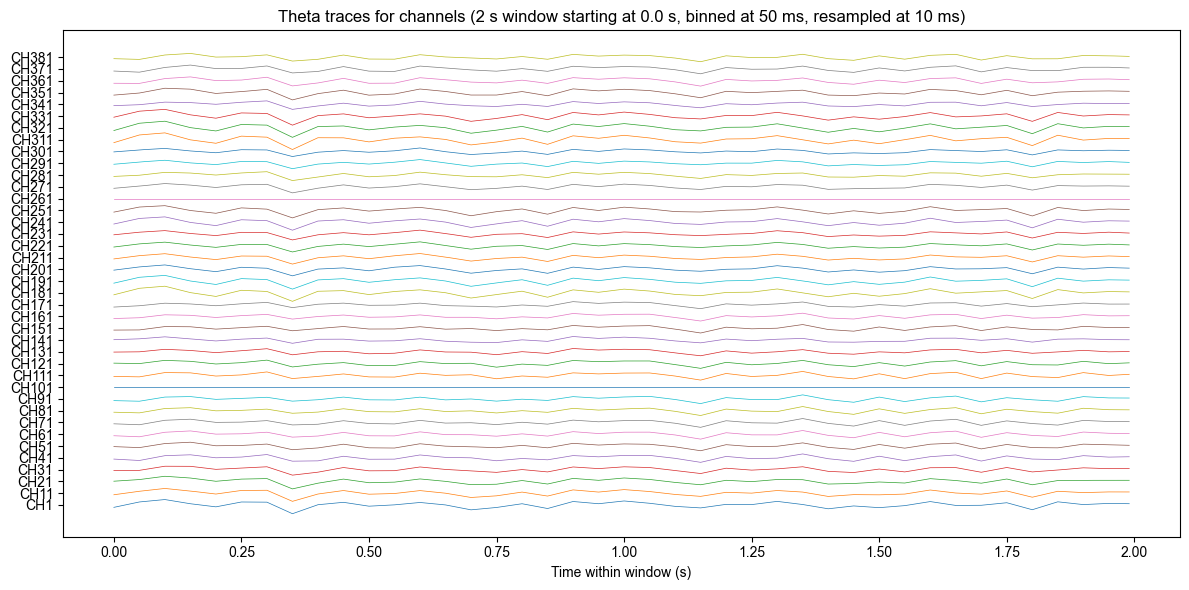

Computing theta trace for CH1, snippet 2...
Computing theta trace for CH11, snippet 2...
Computing theta trace for CH21, snippet 2...
Computing theta trace for CH31, snippet 2...
Computing theta trace for CH41, snippet 2...
Computing theta trace for CH51, snippet 2...
Computing theta trace for CH61, snippet 2...
Computing theta trace for CH71, snippet 2...
Computing theta trace for CH81, snippet 2...
Computing theta trace for CH91, snippet 2...
Computing theta trace for CH101, snippet 2...
Computing theta trace for CH111, snippet 2...
Computing theta trace for CH121, snippet 2...
Computing theta trace for CH131, snippet 2...
Computing theta trace for CH141, snippet 2...
Computing theta trace for CH151, snippet 2...
Computing theta trace for CH161, snippet 2...
Computing theta trace for CH171, snippet 2...
Computing theta trace for CH181, snippet 2...
Computing theta trace for CH191, snippet 2...
Computing theta trace for CH201, snippet 2...
Computing theta trace for CH211, snippet 2...

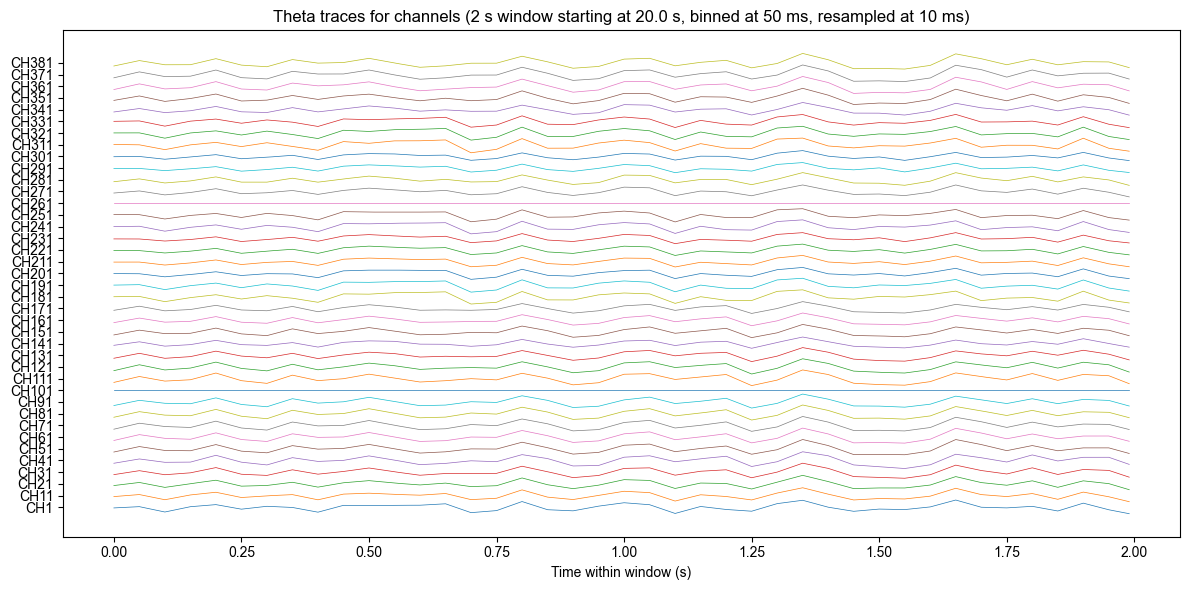

Computing theta trace for CH1, snippet 3...
Computing theta trace for CH11, snippet 3...
Computing theta trace for CH21, snippet 3...
Computing theta trace for CH31, snippet 3...
Computing theta trace for CH41, snippet 3...
Computing theta trace for CH51, snippet 3...
Computing theta trace for CH61, snippet 3...
Computing theta trace for CH71, snippet 3...
Computing theta trace for CH81, snippet 3...
Computing theta trace for CH91, snippet 3...
Computing theta trace for CH101, snippet 3...
Computing theta trace for CH111, snippet 3...
Computing theta trace for CH121, snippet 3...
Computing theta trace for CH131, snippet 3...
Computing theta trace for CH141, snippet 3...
Computing theta trace for CH151, snippet 3...
Computing theta trace for CH161, snippet 3...
Computing theta trace for CH171, snippet 3...
Computing theta trace for CH181, snippet 3...
Computing theta trace for CH191, snippet 3...
Computing theta trace for CH201, snippet 3...
Computing theta trace for CH211, snippet 3...

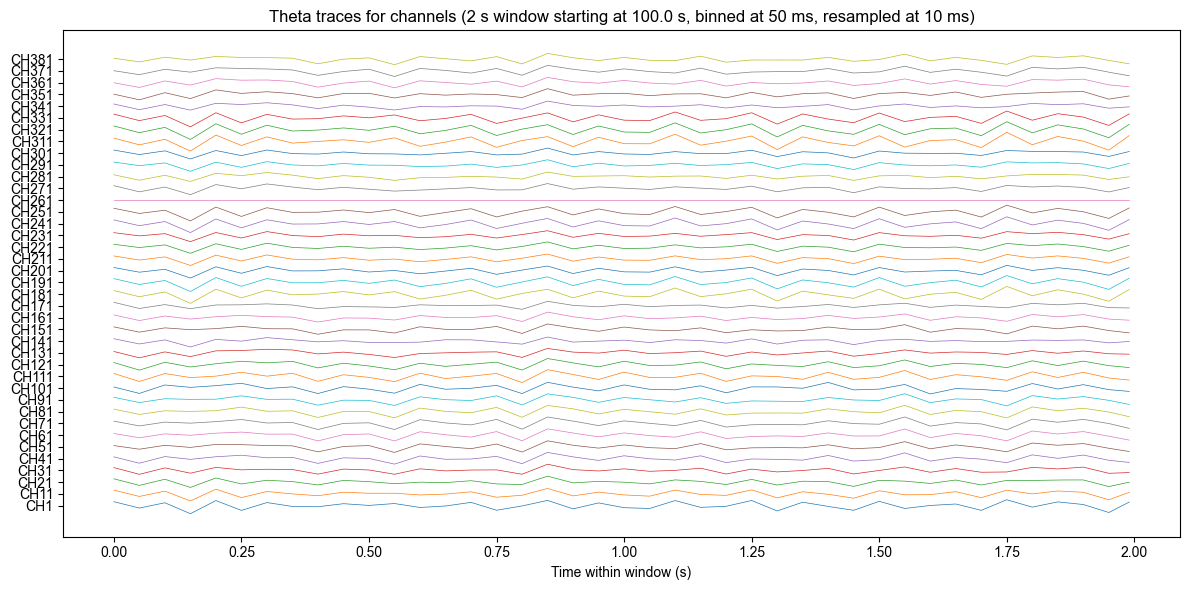

In [7]:
# Plot theta traces for multiple 2 s windows across channels (every 10th channel)
channels = [f"CH{i}" for i in range(1, 385, 10)]  # use every 10th channel for clarity

resample_bs = 10  # ms, for smoother traces (optional)
time_bs_lfp = 50  # ms
window_length_sec = 2.0
bins_per_sec = int(1000 / resample_bs if resample_bs is not None else time_bs_lfp)
window_bins = int(window_length_sec * bins_per_sec)

# Define a few different 2 s snippets (in bins from the start of the recording)
snippet_start_bins = [0, 10*window_bins, 50*window_bins]  # 0–2 s, 2–4 s, 4–6 s (approx.)

for snippet_idx, window_start_idx in enumerate(snippet_start_bins):
    window_end_idx = window_start_idx + window_bins

    theta_traces = []
    for ch in channels:
        print(f"Computing theta trace for {ch}, snippet {snippet_idx + 1}...")
        trace = get_theta_trace(
            mouse=29,
            day=23,
            cluster_id=1,
            time_bs=time_bs_lfp,
            resample_bs=resample_bs,
            vr_type='VR',
            channel=ch
        )
        theta_traces.append(np.array(trace)[window_start_idx:window_end_idx])
    print(f"Length of trace for snippet {snippet_idx + 1}: {len(np.array(trace))}")
    
    theta_traces = np.array(theta_traces)  # shape: (n_channels, window_bins)
    n_channels, n_time = theta_traces.shape  # n_time should equal window_bins

    plt.figure(figsize=(12, 6))
    offset = np.nanmax(np.abs(theta_traces)) * 1.2 if np.isfinite(theta_traces).any() else 1.0

    t_idx = np.arange(n_time) * (resample_bs / 1000 if resample_bs is not None else time_bs_lfp / 1000)

    for i, ch in enumerate(channels):
        plt.plot(t_idx, theta_traces[i] + i * offset, lw=0.5, label=ch if i < 10 else None)

    # Simple y-ticks: label every plotted channel
    yticks = [i * offset for i in range(n_channels)]
    yticklabels = [ch for ch in channels]
    plt.yticks(yticks, yticklabels)

    start_time_sec = window_start_idx / bins_per_sec
    plt.xlabel("Time within window (s)")
    plt.title(
        f"Theta traces for channels (2 s window starting at {start_time_sec:.1f} s, "
        f"binned at {time_bs_lfp} ms, resampled at {resample_bs} ms)"
    )
    plt.tight_layout()
    plt.show()

optimal travel lag is 7.357357357357358 cm based on kde of travel at max spatial information
using travel lag of 7.357357357357358 cm
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm3 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm1 qualifies for spatial cells
brain region ENTm2 qualifies for spatial cells
brain region ENTm2 qualifies for spatial cells
brain region ENTm1 qualifies

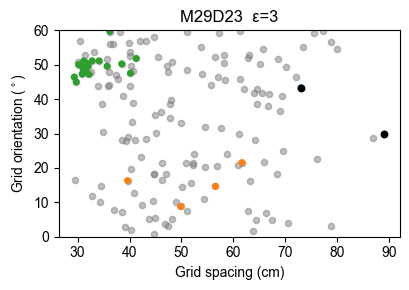

for module 0, there are 4 cells with average spacing 51.90762792615689
for module 1, there are 21 cells with average spacing 33.01008733975044
29 23
for module 1, there are 21 cells
for module 0, there are 4 cells
plotting vr rate maps using cluster_ids [132, 144, 160, 184, 191, 194, 202, 205, 210, 211, 213, 214, 216, 217, 219, 362, 376, 389, 411, 416, 420]


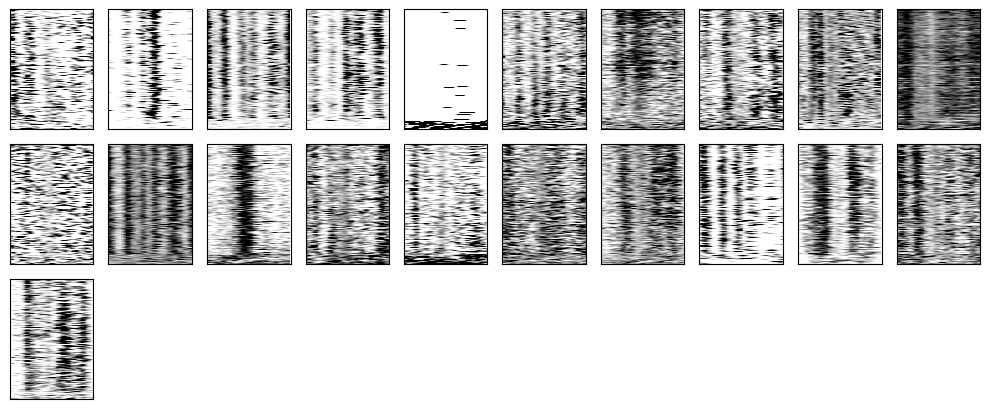

plotting vr rate maps using cluster_ids [332, 341, 425, 430]


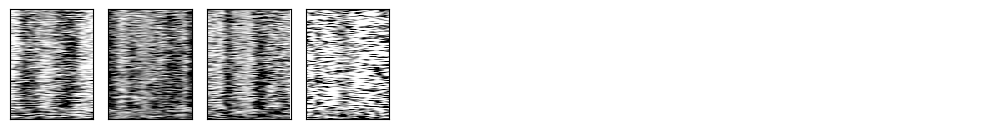

plotting vr rate maps using cluster_ids [20, 24, 28, 29, 30, 32, 33, 34, 53, 61, 65, 79, 81, 86, 89, 95, 104, 108, 133, 157, 163, 169, 186, 198, 221, 226, 231, 239, 241, 244, 247, 249, 251, 255, 256, 259, 266, 267, 269, 270, 272, 278, 292, 293, 296, 297, 301, 311, 312, 315, 318, 321, 323, 327, 329, 334, 340, 342, 345, 346, 349, 350, 352, 353, 354, 356, 363, 364, 366, 368, 369, 370, 371, 373, 374, 375, 377, 378, 380, 382, 383, 387, 388, 391, 392, 393, 394, 396, 397, 398, 399, 400, 403, 404, 405, 409, 412, 414, 418, 419, 422, 426, 427, 429, 433, 434, 440, 446, 450, 451, 452, 454, 457, 461, 462, 464, 466, 467, 469, 472]


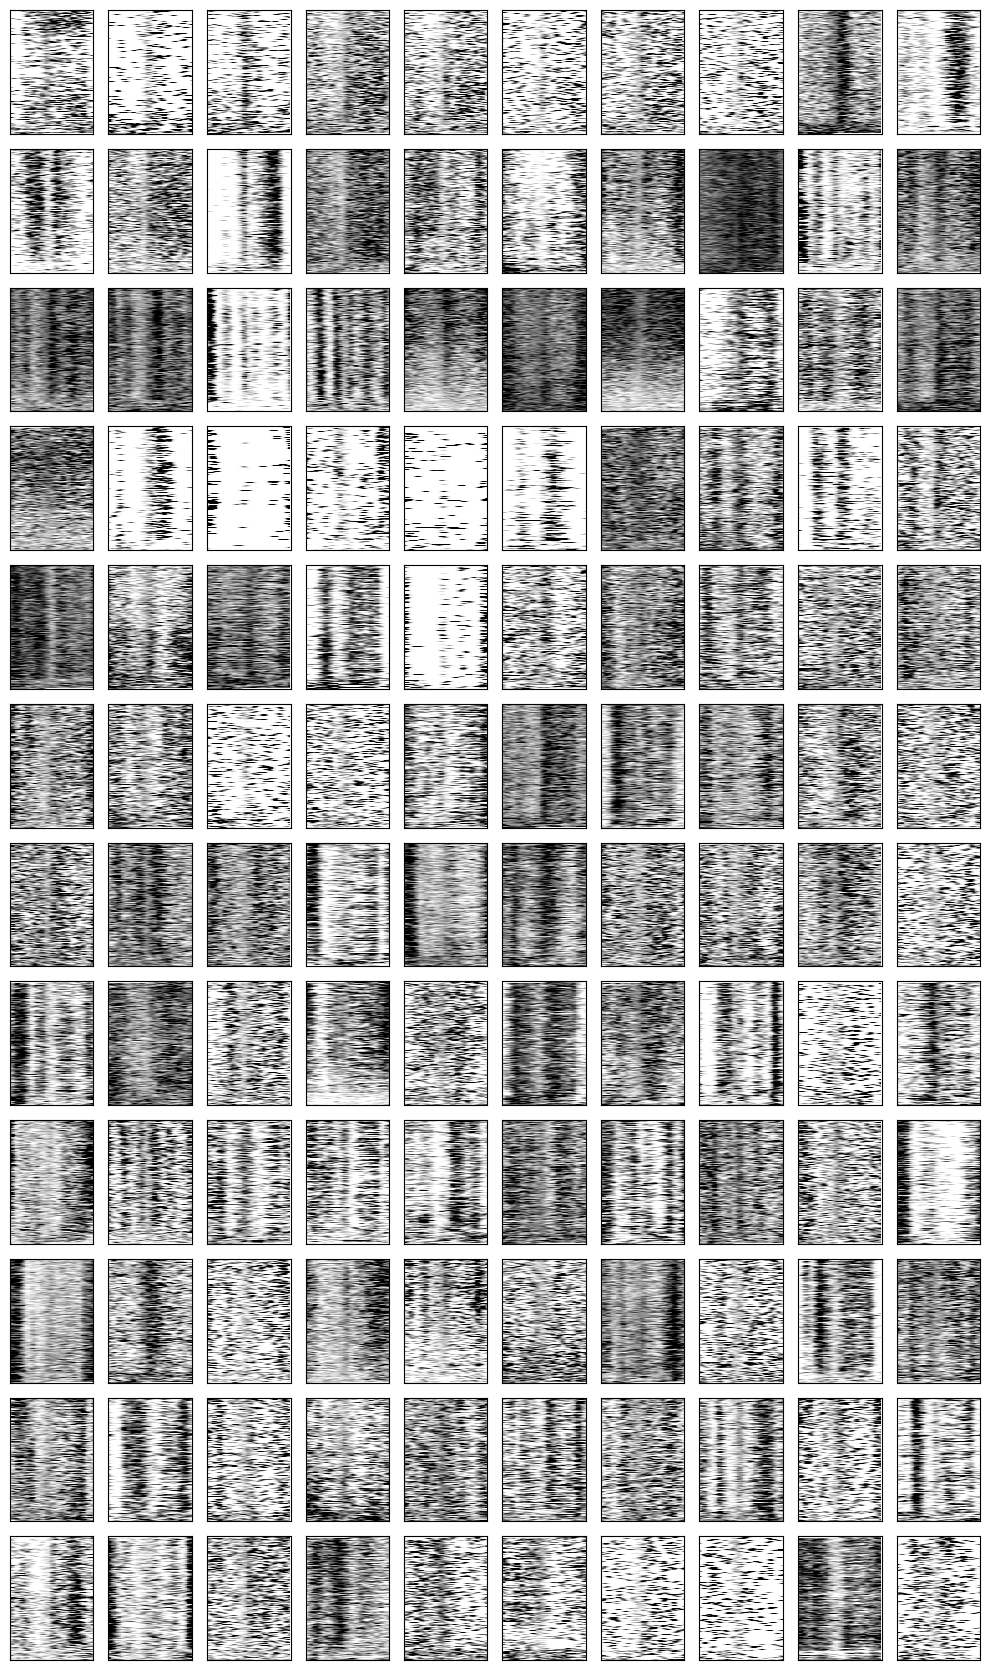

plotting vr rate maps using cluster_ids [26, 268, 275, 317, 335, 336, 359, 408, 444, 447, 458, 459, 463]


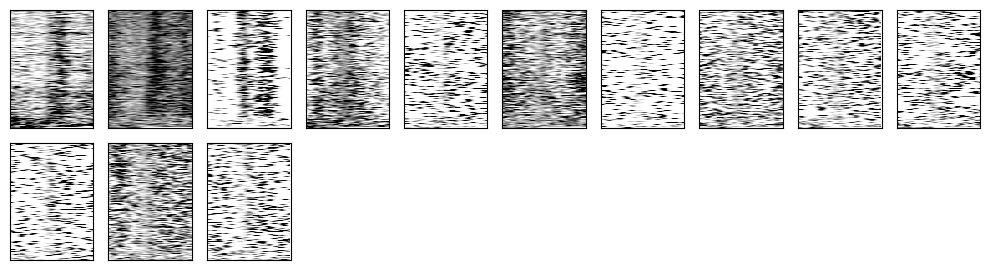

plotting vr rate maps using cluster_ids [132, 144, 160, 184, 191, 194, 202, 205, 210, 211, 213, 214, 216, 217, 219, 332, 341, 343, 362, 376, 385, 389, 411, 416, 420, 425, 430]


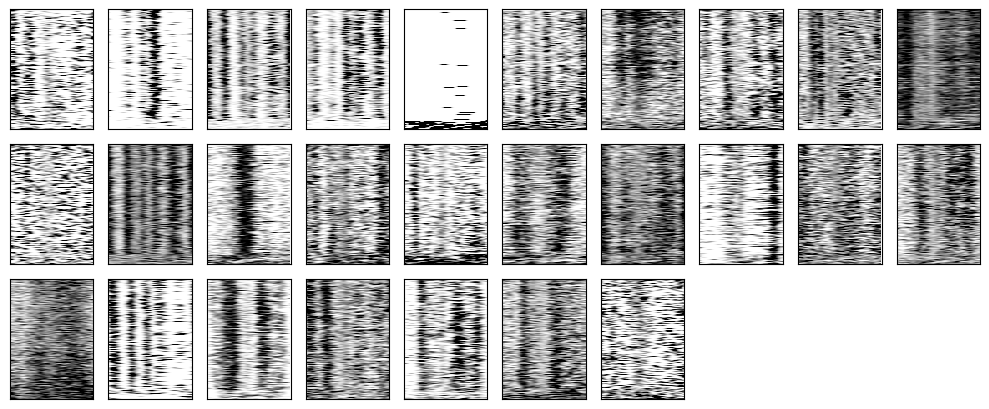

plotting vr rate maps using cluster_ids []
plotting vr rate maps using cluster_ids [332 341 343 385 425 430]


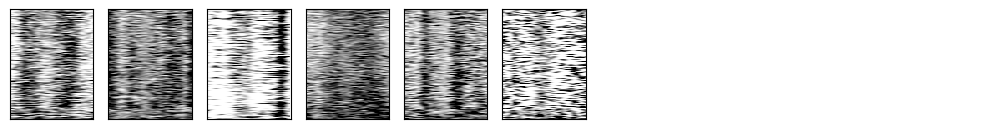

In [8]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset

gcs, ngs, all = classify_cells_both_sessions(mouse, day)
# derive remaining cell groups from the combined classification
_gcs_ids = set(gcs['cluster_id']) if len(gcs) > 0 else set()
_ngs_ids = set(ngs['cluster_id']) if len(ngs) > 0 else set()
gc_ngs_ids = _gcs_ids.union(_ngs_ids)
ns = all[~all['cluster_id'].isin(gc_ngs_ids)].copy().reset_index(drop=True)

rc, rsc, vr_ns = cell_classification_vr(mouse, day)
mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)
g_m_ids, g_m_cluster_ids, _ = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

plot_vr_rate_maps(mouse, day, np.setdiff1d(gcs.cluster_id.values, g_m_cluster_ids[0]), label=f'nocomodular_grid_cells', figpath=fig_path)

In [9]:
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)
tcs_of, tcs_time_of, beh_of, clusters_of, ep_OF = compute_of_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False, optimal_shift=gcs.travel[0])
last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]
print(len(pos_in_time), len(speed_in_time), len(trial_number_in_time))

x_pos_in_time_OF = np.array(beh_of['head_x'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep_OF))
y_pos_in_time_OF = np.array(beh_of['head_y'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep_OF))

if np.any(np.isnan(pos_in_time)):
    series = pd.Series(dt_in_time)
    filled_series = series.ffill().bfill()
    dt_in_time = np.array(filled_series)
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(speed_in_time)):
    series = pd.Series(speed_in_time)
    filled_series = series.ffill().bfill()
    speed_in_time = np.array(speed_in_time)

if np.any(np.isnan(x_pos_in_time_OF)):
    series = pd.Series(x_pos_in_time_OF)
    filled_series = series.ffill().bfill()
    x_pos_in_time_OF = np.array(filled_series)

if np.any(np.isnan(y_pos_in_time_OF)):
    series = pd.Series(y_pos_in_time_OF)
    filled_series = series.ffill().bfill()
    y_pos_in_time_OF = np.array(filled_series)

192467 192467 192467


In [10]:
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = 1000)

In [11]:
test_grid_cell_1 = 214  # cm
test_grid_cell_2 = 332  # ncm
test_ngs_cell_1 = 340   # ngs

import random

# Prepare grid predictors (remove test cells if present, then shuffle and select 10)
grid_predictors = g_m_cluster_ids[0].copy()
for test_id in [test_grid_cell_1, test_grid_cell_2, test_ngs_cell_1]:
    if test_id in grid_predictors:
        grid_predictors.remove(test_id)
random.shuffle(grid_predictors)
grid_predictors = grid_predictors[:10]

# Prepare NGS predictors (remove test cells if present, then shuffle and select 10)
ngs_predictors = ngs.cluster_id.values.tolist()
for test_id in [test_grid_cell_1, test_grid_cell_2, test_ngs_cell_1]:
    if test_id in ngs_predictors:
        ngs_predictors.remove(test_id)
random.shuffle(ngs_predictors)
ngs_predictors = ngs_predictors[:10]

In [12]:
def predict_xgboost_traces(
    target_id,
    tcs_time,
    pos_in_time,
    speed_in_time,
    grid_predictors,
    ngs_predictors,
    xgb_history,
    gaussian_filter_nan,
    n_grid=10,
    n_ngs=10,
    mouse=29,
    day=23
):
    """
    Predicts activity for a target cell using XGBoost with various covariate sets.

    Returns a dictionary of predictions and cross-validated pR2 values.
    """
    y = np.array(tcs_time[target_id])
    y_smoothed = gaussian_filter_nan(y, sigma=3)
    
    # --- LFP (theta) ---
    lfp = get_theta_trace(
        mouse=mouse,
        day=day,
        cluster_id=target_id,
        time_bs=50,
        resample_bs=time_bs,  # assumes global time_bs
        vr_type='VR'
    )
    # Make lfp the same length as y by trimming or zero-padding as needed
    if len(lfp) < len(y):
        lfp = np.pad(lfp, (0, len(y) - len(lfp)), mode='constant')
    else:
        lfp = lfp[:len(y)]

    # --- SPEED ---
    speed = np.array(speed_in_time)
    # Make speed the same length as y by trimming or zero-padding as needed
    if len(speed) < len(y):
        speed = np.pad(speed, (0, len(y) - len(speed)), mode='constant')
    else:
        speed = speed[:len(y)]

    # --- POSITION ONLY ---
    pos = np.array(pos_in_time)
    if len(pos) < len(y):
        pos = np.pad(pos, (0, len(y) - len(pos)), mode='constant')
    else:
        pos = pos[:len(y)]

    # --- GRID CELLS ---
    Xg_1 = np.stack([np.array(tcs_time[grid_predictors[0]])]).T
    Xpos_g_1 = np.stack([pos, np.array(tcs_time[grid_predictors[0]])]).T

    Xg_5 = np.column_stack([np.array(tcs_time[cid]) for cid in grid_predictors[:5]])
    Xpos_g_5 = np.column_stack((pos, Xg_5))

    Xg_10 = np.column_stack([np.array(tcs_time[cid]) for cid in grid_predictors[:n_grid]])
    Xpos_g_10 = np.column_stack((pos, Xg_10))

    # --- NGS CELLS ---
    Xngs_1 = np.stack([np.array(tcs_time[ngs_predictors[0]])]).T
    Xpos_ngs_1 = np.stack([pos, np.array(tcs_time[ngs_predictors[0]])]).T

    Xngs_5 = np.column_stack([np.array(tcs_time[cid]) for cid in ngs_predictors[:5]])
    Xpos_ngs_5 = np.column_stack((pos, Xngs_5))

    Xngs_10 = np.column_stack([np.array(tcs_time[cid]) for cid in ngs_predictors[:n_ngs]])
    Xpos_ngs_10 = np.column_stack((pos, Xngs_10))

    # --- POSITION / LFP / SPEED BASES ---
    Xpos = pos[:, None]
    Xlfp = lfp[:, None]
    Xspeed = speed[:, None]

    Xpos_lfp = np.column_stack((pos, lfp))
    Xpos_speed = np.column_stack((pos, speed))
    Xspeed_lfp = np.column_stack((speed, lfp))
    Xpos_speed_lfp = np.column_stack((pos, speed, lfp))

    # --- LFP WITH CELLS ---
    Xg_10_lfp = np.column_stack((Xg_10, lfp))
    Xngs_10_lfp = np.column_stack((Xngs_10, lfp))
    Xpos_g_10_lfp = np.column_stack((pos, Xg_10, lfp))
    Xpos_ngs_10_lfp = np.column_stack((pos, Xngs_10, lfp))

    # --- SPEED WITH CELLS (± position / LFP) ---
    # Grid
    Xg_10_speed = np.column_stack((Xg_10, speed))
    Xg_10_speed_lfp = np.column_stack((Xg_10, speed, lfp))
    Xpos_g_10_speed = np.column_stack((pos, Xg_10, speed))
    Xpos_g_10_speed_lfp = np.column_stack((pos, Xg_10, speed, lfp))

    # NGS
    Xngs_10_speed = np.column_stack((Xngs_10, speed))
    Xngs_10_speed_lfp = np.column_stack((Xngs_10, speed, lfp))
    Xpos_ngs_10_speed = np.column_stack((pos, Xngs_10, speed))
    Xpos_ngs_10_speed_lfp = np.column_stack((pos, Xngs_10, speed, lfp))

    # --- FIT MODELS ---
    results = {}

    # Position only
    results['pos'] = xgb_history.fit_cv(Xpos, y, verbose=0, continuous_folds=True)

    # LFP only
    results['lfp'] = xgb_history.fit_cv(Xlfp, y, verbose=0, continuous_folds=True)

    # Speed only
    results['speed'] = xgb_history.fit_cv(Xspeed, y, verbose=0, continuous_folds=True)

    # Position + LFP / speed / both
    results['pos_lfp'] = xgb_history.fit_cv(Xpos_lfp, y, verbose=0, continuous_folds=True)
    results['pos_speed'] = xgb_history.fit_cv(Xpos_speed, y, verbose=0, continuous_folds=True)
    results['speed_lfp'] = xgb_history.fit_cv(Xspeed_lfp, y, verbose=0, continuous_folds=True)
    results['pos_speed_lfp'] = xgb_history.fit_cv(Xpos_speed_lfp, y, verbose=0, continuous_folds=True)

    # Grid predictors
    results['g1'] = xgb_history.fit_cv(Xg_1, y, verbose=0, continuous_folds=True)
    results['g5'] = xgb_history.fit_cv(Xg_5, y, verbose=0, continuous_folds=True)
    results['g10'] = xgb_history.fit_cv(Xg_10, y, verbose=0, continuous_folds=True)
    results['g10_lfp'] = xgb_history.fit_cv(Xg_10_lfp, y, verbose=0, continuous_folds=True)

    # Grid predictors + position
    results['pos_g1'] = xgb_history.fit_cv(Xpos_g_1, y, verbose=0, continuous_folds=True)
    results['pos_g5'] = xgb_history.fit_cv(Xpos_g_5, y, verbose=0, continuous_folds=True)
    results['pos_g10'] = xgb_history.fit_cv(Xpos_g_10, y, verbose=0, continuous_folds=True)
    results['pos_g10_lfp'] = xgb_history.fit_cv(Xpos_g_10_lfp, y, verbose=0, continuous_folds=True)

    # Grid predictors + speed / speed+LFP / pos+speed / pos+speed+LFP
    results['g10_speed'] = xgb_history.fit_cv(Xg_10_speed, y, verbose=0, continuous_folds=True)
    results['g10_speed_lfp'] = xgb_history.fit_cv(Xg_10_speed_lfp, y, verbose=0, continuous_folds=True)
    results['pos_g10_speed'] = xgb_history.fit_cv(Xpos_g_10_speed, y, verbose=0, continuous_folds=True)
    results['pos_g10_speed_lfp'] = xgb_history.fit_cv(Xpos_g_10_speed_lfp, y, verbose=0, continuous_folds=True)

    # NGS predictors
    results['ngs1'] = xgb_history.fit_cv(Xngs_1, y, verbose=0, continuous_folds=True)
    results['ngs5'] = xgb_history.fit_cv(Xngs_5, y, verbose=0, continuous_folds=True)
    results['ngs10'] = xgb_history.fit_cv(Xngs_10, y, verbose=0, continuous_folds=True)
    results['ngs10_lfp'] = xgb_history.fit_cv(Xngs_10_lfp, y, verbose=0, continuous_folds=True)

    # NGS predictors + position
    results['pos_ngs1'] = xgb_history.fit_cv(Xpos_ngs_1, y, verbose=0, continuous_folds=True)
    results['pos_ngs5'] = xgb_history.fit_cv(Xpos_ngs_5, y, verbose=0, continuous_folds=True)
    results['pos_ngs10'] = xgb_history.fit_cv(Xpos_ngs_10, y, verbose=0, continuous_folds=True)
    results['pos_ngs10_lfp'] = xgb_history.fit_cv(Xpos_ngs_10_lfp, y, verbose=0, continuous_folds=True)

    # NGS predictors + speed / speed+LFP / pos+speed / pos+speed+LFP
    results['ngs10_speed'] = xgb_history.fit_cv(Xngs_10_speed, y, verbose=0, continuous_folds=True)
    results['ngs10_speed_lfp'] = xgb_history.fit_cv(Xngs_10_speed_lfp, y, verbose=0, continuous_folds=True)
    results['pos_ngs10_speed'] = xgb_history.fit_cv(Xpos_ngs_10_speed, y, verbose=0, continuous_folds=True)
    results['pos_ngs10_speed_lfp'] = xgb_history.fit_cv(Xpos_ngs_10_speed_lfp, y, verbose=0, continuous_folds=True)

    # Also return the true and smoothed target for plotting
    results['y'] = y
    results['y_smoothed'] = y_smoothed

    results[' '] = (y*np.nan, np.zeros(10).tolist()) # Placeholder for any additional info if needed
    return results

In [13]:
# Example for three target cells
target_cell_names = [f'Unit {test_grid_cell_1}', f'Unit {test_grid_cell_2}', f'Unit {test_ngs_cell_1}']
target_cell_ids = [test_grid_cell_1, test_grid_cell_2, test_ngs_cell_1]

# Run predictions for each target cell and collect results
results_dict = {}
for cell_name, cell_id in zip(target_cell_names, target_cell_ids):
    results_dict[cell_name] = predict_xgboost_traces(
        target_id=cell_id,
        tcs_time=tcs_time,
        pos_in_time=pos_in_time,
        speed_in_time=speed_in_time,
        grid_predictors=grid_predictors,
        ngs_predictors=ngs_predictors,
        xgb_history=xgb_history,
        gaussian_filter_nan=gaussian_filter_nan,
        n_grid=10,
        n_ngs=10
    )

In [14]:
def make_tidy_labels(covariate_labels):
    """
    Map raw covariate labels to human-readable tidy labels.

    Any covariate not in the mapping is returned unchanged.
    """
    mapping = {
        # Base covariates
        'pos': 'Pos (P)',
        'lfp': 'LFP',
        'speed': 'Speed (S)',
        ' ': ' ',  # for the empty separator

        # Base combinations
        'pos_lfp': 'LFP+P',
        'pos_speed': 'S+P',
        'speed_lfp': 'S+LFP',
        'pos_speed_lfp': 'S+LFP+P',

        # Grid-only
        'g1': 'GCn=1',
        'g5': 'GCn=5',
        'g10': 'GCn=10',

        # Grid + LFP
        'g10_lfp': 'LFP+GCn=10',

        # Grid + speed
        'g10_speed': 'S+GCn=10',
        'g10_speed_lfp': 'S+LFP+GCn=10',

        # Grid + position (± LFP / speed)
        'pos_g1': 'P+GCn=1',
        'pos_g5': 'P+GCn=5',
        'pos_g10': 'P+GCn=10',
        'pos_g10_lfp': 'LFP+P+GCn=10',
        'pos_g10_speed': 'S+P+GCn=10',
        'pos_g10_speed_lfp': 'S+LFP+P+GCn=10',

        # NGS-only
        'ngs1': 'NGSn=1',
        'ngs5': 'NGSn=5',
        'ngs10': 'NGSn=10',

        # NGS + LFP
        'ngs10_lfp': 'LFP+NGSn=10',

        # NGS + speed
        'ngs10_speed': 'S+NGSn=10',
        'ngs10_speed_lfp': 'S+LFP+NGSn=10',

        # NGS + position (± LFP / speed)
        'pos_ngs1': 'P+NGSn=1',
        'pos_ngs5': 'P+NGSn=5',
        'pos_ngs10': 'P+NGSn=10',
        'pos_ngs10_lfp': 'LFP+P+NGSn=10',
        'pos_ngs10_speed': 'S+P+NGSn=10',
        'pos_ngs10_speed_lfp': 'S+LFP+P+NGSn=10',
    }
    tidy = []
    for cov in covariate_labels:
        tidy.append(mapping.get(cov, cov))
    return tidy


def plot_xgboost_traces(
    results_dict,
    target_cell_names,
    covariate_labels=[
        'pos', 'speed', 'lfp', 
        'pos_speed', 'pos_lfp', 'speed_lfp', 'pos_speed_lfp',
        ' ',
        'g1', 'g5', 'g10', 'g10_lfp',
        'pos_g1', 'pos_g5', 'pos_g10', 'pos_g10_lfp',
        'g10_speed', 'g10_speed_lfp', 'pos_g10_speed', 'pos_g10_speed_lfp',
        ' ',
        'ngs1', 'ngs5', 'ngs10', 'ngs10_lfp',
        'pos_ngs1', 'pos_ngs5', 'pos_ngs10', 'pos_ngs10_lfp',
        'ngs10_speed', 'ngs10_speed_lfp', 'pos_ngs10_speed', 'pos_ngs10_speed_lfp',
    ],
    tidy_covariate_labels=None,
    true_labels=['y', 'y_smoothed'],
    window=None,
    figsize=(15, 4),
    gain=[1, 1, 1],
    text_offset=0.0,
    offset_jump=0.0,
    savepath=None,
    time_bs=100,  # ms per bin, adjust as needed
):
    """
    Plot true and predicted traces for target cells side by side using results_dict directly.

    Each covariate prediction is offset vertically for clarity.
    true_labels are plotted at the top, overlayed, in black and grey (same offset).
    Covariate label on left, mean pR2 on right. No axes.

    Offsets are fixed and identical across all subplots.
    Colors: test_grid_cell_1 and test_grid_cell_2 = red, test_ngs_cell_1 = blue.
    text_offset: vertical shift of text annotations (in units of offset_step).
    offset_jump: optional extra spacing between the true trace and the first covariate.
    tidy_covariate_labels: if None, they are generated from covariate_labels via make_tidy_labels.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    def subscript_n(label):
        import re

        # Replace "n=10" → "$_{n=10}$" inside the label, e.g. "GCn=10" → "GC$_{n=10}$"
        def repl(match):
            n_val = match.group(1)
            return r'$_{n=' + n_val + '}$'

        return re.sub(r'n=([0-9]+)', repl, label)

    # Build tidy labels if not provided
    if tidy_covariate_labels is None:
        tidy_covariate_labels = make_tidy_labels(covariate_labels)
    if len(tidy_covariate_labels) != len(covariate_labels):
        raise ValueError(
            f"tidy_covariate_labels must have the same length as covariate_labels "
            f"({len(tidy_covariate_labels)} vs {len(covariate_labels)})"
        )

    # Ordered labels: first the main true trace label, then all covariates in the user-given order
    ordered_labels = [true_labels[0]] + list(covariate_labels)
    n_offsets = len(ordered_labels)

    # Compute a global offset step based on all true traces
    all_true_traces = [results_dict[cell]["y"] for cell in target_cell_names]
    if len(all_true_traces) > 0:
        print(f"Length of y (time bins): {len(all_true_traces[0])}")
    if window is not None:
        all_true_traces = [trace[window[0]:window[1]] for trace in all_true_traces]
    global_max = np.nanmax([np.nanmax(trace) for trace in all_true_traces])
    offset_step = global_max * 1.2 if global_max > 0 else 1

    # Build vertical offsets; allow a jump after the first covariate if desired
    offsets = []
    for i, label in enumerate(ordered_labels):
        jump = 0.0
        if i == 1:  # right after the true trace
            jump = offset_jump * offset_step
        if i == 0:
            offsets.append(offset_step * (n_offsets - 1 - i))
        else:
            offsets.append(offsets[-1] - offset_step - jump)

    # Assign colors by test cell: red for grid cells, blue for ngs
    color_map_by_cell = {}
    for cell_name in target_cell_names:
        if '340' in str(cell_name).lower():
            color_map_by_cell[cell_name] = '#3171ae'
        else:
            color_map_by_cell[cell_name] = '#c04744'
    true_label_colors = ['grey', 'black']

    n_cells = len(target_cell_names)
    fig, axes = plt.subplots(1, n_cells, figsize=figsize, sharey=True)
    if n_cells == 1:
        axes = [axes]

    for i, cell_name in enumerate(target_cell_names):
        ax = axes[i]
        true_trace = results_dict[cell_name]["y"]
        if window is not None:
            t_idx = np.arange(window[0], window[1])
            true_trace = true_trace[window[0]:window[1]]
        else:
            t_idx = np.arange(len(true_trace))

        # Plot true labels at the top, overlayed, with same offset
        true_offset = offsets[0]
        for j, label in enumerate(true_labels):
            if label in results_dict[cell_name]:
                trace = results_dict[cell_name][label]
                if window is not None:
                    trace = trace[window[0]:window[1]]
                ax.plot(
                    t_idx,
                    trace * 2 + true_offset,
                    lw=2,
                    color=true_label_colors[j],
                    alpha=0.8,
                )
                if i == 0:
                    ax.text(
                        t_idx[0] - (0.08 * len(t_idx)),  # shift left of y axis label
                        np.nanmean(trace * 2 + true_offset) + text_offset * offset_step,
                        label,
                        color=true_label_colors[j],
                        va='center',
                        ha='right',
                        fontsize=15,
                    )

        # Plot predictions for each covariate, using the same order as covariate_labels
        for j, cov_label in enumerate(covariate_labels):
            idx = ordered_labels.index(cov_label)
            pred_trace = results_dict[cell_name][cov_label][0]
            if window is not None:
                pred_trace = pred_trace[window[0]:window[1]]
            pr2 = np.nanmean(results_dict[cell_name][cov_label][1])
            color = color_map_by_cell[cell_name]
            offset = offsets[idx]

            tidy_label = subscript_n(tidy_covariate_labels[j])

            if i == 0:
                ax.text(
                    t_idx[0] - (0.08 * len(t_idx)),  # shift left of y axis label
                    np.nanmean(pred_trace + offset) + text_offset * offset_step,
                    tidy_label,
                    color=color,
                    va='center',
                    ha='right',
                    fontsize=15,
                )
            print(f"Plotting {cov_label} for {cell_name} with pR2={pr2:.4f}")
            print(f'shape of pred_trace: {pred_trace.shape}, length of t_idx: {len(t_idx)}')
            ax.plot(t_idx, pred_trace * gain[i] + offset, lw=1.5, alpha=0.8, color=color)
            ax.text(
                t_idx[-1] + (0.01 * len(t_idx)),
                np.nanmean(pred_trace + offset) + text_offset * offset_step,
                f'{pr2:.2f}',
                color=color,
                va='center',
                ha='left',
                fontsize=10,
            )

        ax.set_title(str(cell_name), fontsize=16)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')

    # Add y axis label to the leftmost plot
    axes[0].set_ylabel('Target prediction', fontsize=18, labelpad=60)

    # Plot a 5 s scale bar on the leftmost axis
    if window is not None:
        t_start = window[0]
    else:
        t_start = 0
    t_per_bin = time_bs / 1000.0  # convert ms to s
    bar_len = int(5 / t_per_bin)
    axes[0].plot([t_start, t_start + bar_len], [offsets[-1], offsets[-1]], color='black', lw=2)

    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath)
    plt.show()

In [15]:
results_dict['Unit 214']['pos'][0]


array([0.37765846, 0.50286013, 0.42070356, ..., 0.47286484, 0.48563564,
       0.48505348])

Length of y (time bins): 192467
Plotting pos for Unit 214 with pR2=0.0511
shape of pred_trace: (2000,), length of t_idx: 2000
Plotting speed for Unit 214 with pR2=0.0085
shape of pred_trace: (2000,), length of t_idx: 2000
Plotting lfp for Unit 214 with pR2=0.0192
shape of pred_trace: (2000,), length of t_idx: 2000
Plotting pos_speed for Unit 214 with pR2=0.0508
shape of pred_trace: (2000,), length of t_idx: 2000
Plotting pos_lfp for Unit 214 with pR2=0.0598
shape of pred_trace: (2000,), length of t_idx: 2000
Plotting speed_lfp for Unit 214 with pR2=0.0235
shape of pred_trace: (2000,), length of t_idx: 2000
Plotting pos_speed_lfp for Unit 214 with pR2=0.0600
shape of pred_trace: (2000,), length of t_idx: 2000
Plotting   for Unit 214 with pR2=0.0000
shape of pred_trace: (2000,), length of t_idx: 2000
Plotting g1 for Unit 214 with pR2=0.0033
shape of pred_trace: (2000,), length of t_idx: 2000
Plotting g5 for Unit 214 with pR2=0.0297
shape of pred_trace: (2000,), length of t_idx: 2000
Plot

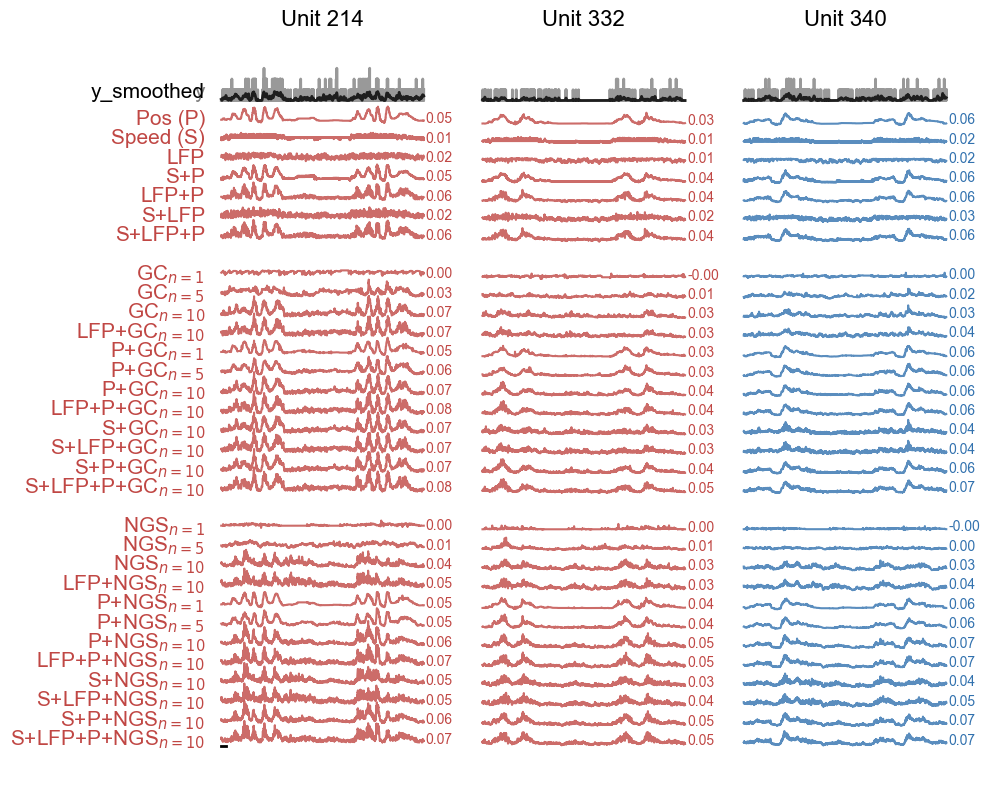

In [18]:
b=-30000
# Now you can call the plotting function
plot_xgboost_traces(results_dict, 
                    target_cell_names,
                    window=(24150, 26150), 
                    figsize=(10, 8),
                    gain=[5, 12, 6],
                    text_offset=0.25,
                    offset_jump=0.3,
                    savepath=f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/M{mouse}D{day}_xgboost_traces_with_theta.pdf')

using expected spikes for cell 26
using expected spikes for cell 29
using expected spikes for cell 30
using expected spikes for cell 32
using expected spikes for cell 33
using expected spikes for cell 34
using expected spikes for cell 268
using expected spikes for cell 275
using expected spikes for cell 317
using expected spikes for cell 335
using expected spikes for cell 336
using expected spikes for cell 359
using expected spikes for cell 408
using expected spikes for cell 444
using expected spikes for cell 447
using expected spikes for cell 458
using expected spikes for cell 459
using expected spikes for cell 463


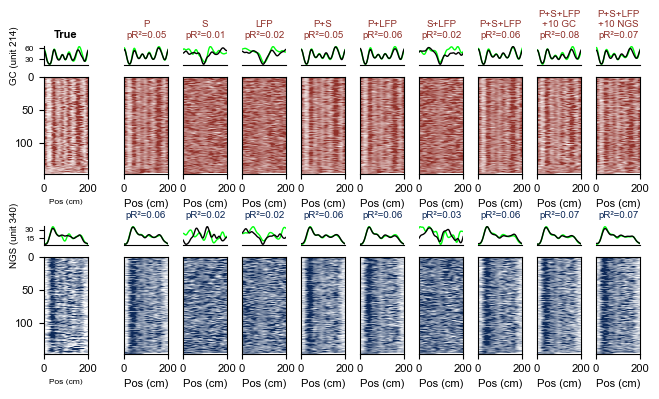

Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/M29D23_rate_map_reconstruction_2x10.pdf


In [ ]:
from scipy.ndimage import gaussian_filter
from matplotlib.ticker import MaxNLocator
import matplotlib.gridspec as gridspec

# ── Config ────────────────────────────────────────────────────────────────────
plot_keys  = ['pos', 'speed', 'lfp',
              'pos_speed', 'pos_lfp', 'speed_lfp', 'pos_speed_lfp',
              'pos_g10_speed_lfp', 'pos_ngs10_speed_lfp']
col_titles = ['P', 'S', 'LFP', 'P+S', 'P+LFP', 'S+LFP', 'P+S+LFP',
              'P+S+LFP\n+10 GC', 'P+S+LFP\n+10 NGS']

target_cells = [
    (test_grid_cell_1, f'GC (unit {test_grid_cell_1})',  '#90312a'),
    (test_ngs_cell_1,  f'NGS (unit {test_ngs_cell_1})', '#0d2958'),
]
row_results = [
    results_dict[f'Unit {test_grid_cell_1}'],
    results_dict[f'Unit {test_ngs_cell_1}'],
]

# ── Pool real cluster IDs as pseudo IDs ───────────────────────────────────────
exclude_ids = {test_grid_cell_1, test_grid_cell_2, test_ngs_cell_1}
pool_ids = []
for src in [ns.cluster_id.values, sc.cluster_id.values, all_by_anatomy.cluster_id.values]:
    for cid in src:
        if cid not in exclude_ids and cid not in pool_ids:
            pool_ids.append(cid)

n_needed = len(plot_keys)
assert len(pool_ids) >= n_needed * 2, \
    f"Need {n_needed*2} pseudo IDs, found {len(pool_ids)}"
pseudo_ids_gc  = pool_ids[:n_needed]
pseudo_ids_ngs = pool_ids[n_needed:n_needed * 2]

# ── Batch Y_hat arrays → single reconstruction call ───────────────────────────
expected_spikes = {}
for col_i, key in enumerate(plot_keys):
    expected_spikes[pseudo_ids_gc[col_i]]  = row_results[0][key][0]
    expected_spikes[pseudo_ids_ngs[col_i]] = row_results[1][key][0]

tcs_recon, _, _, last_ephys_bin_r, _, _ = compute_vr_tcs_using_expected_spikes(
    mouse, day, apply_zscore=False, vr_type='VR', source_path=None,
    expected_spikes=expected_spikes)

# ── Trial groups for avg profile ──────────────────────────────────────────────
trial_groups, trial_colors = get_trial_groups_and_colors(
    beh, last_ephys_bin, tl, bs, ignore_performance=True)

def plot_avg_profile(ax, tc, bs, tl, trial_groups, trial_colors, show_yticks=True):
    for group in np.unique(trial_groups):
        if len(trial_groups[trial_groups == group]) > 5:
            x, y_avg = get_avg_profile(tc, bs, tl, mask=trial_groups == group)
            ax.plot(x, y_avg, color=trial_colors[trial_groups == group][0], linewidth=1)
    ax.set_xlim(0, tl)
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if show_yticks:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=2))
        ax.tick_params(axis='y', labelsize=6)
    else:
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)

def white_to_hex_cmap(hex_color, name='custom_cmap'):
    from matplotlib.colors import LinearSegmentedColormap
    return LinearSegmentedColormap.from_list(name, ['#FFFFFF', hex_color])

# ── Layout ────────────────────────────────────────────────────────────────────
# 5 subrows: GC avg | GC rm | ROW GAP | NGS avg | NGS rm
# N_COLS: true | col gap | predictions x9
N_PRED  = len(plot_keys)   # 9
N_COLS  = 1 + 1 + N_PRED  # 11
GAP_COL = 1
sigma   = 2.5

# width_ratios: data cols = 1.0, gap col = 0.15
col_widths = [1.0] + [0.15] + [1.0] * N_PRED

fig = plt.figure(figsize=(N_COLS * 0.7, 4))
gs  = gridspec.GridSpec(
    5, N_COLS, figure=fig,
    height_ratios=[0.2, 1, 0.3, 0.2, 1],
    width_ratios=col_widths,
    hspace=0.22,
    wspace=0.35,
)

# subrow indices per target
subrows = [
    (0, 1),   # GC:  avg=0, rm=1
    (3, 4),   # NGS: avg=3, rm=4
]

for row_i, (target_id, row_label, color) in enumerate(target_cells):
    results    = row_results[row_i]
    pseudo_ids = pseudo_ids_gc if row_i == 0 else pseudo_ids_ngs
    sr_avg, sr_rm = subrows[row_i]

    # ── Col 0: True ───────────────────────────────────────────────────────────
    tc_true = gaussian_filter(
        np.nan_to_num(tcs[target_id]).astype(np.float64), sigma=sigma)
    tc_true = tc_true[:last_ephys_bin]

    ax_avg = fig.add_subplot(gs[sr_avg, 0])
    ax_rm  = fig.add_subplot(gs[sr_rm,  0])

    plot_avg_profile(ax_avg, tc_true, bs, tl, trial_groups, trial_colors, show_yticks=True)
    ax_avg.set_ylabel(row_label, fontsize=7, labelpad=4)
    if row_i == 0:
        ax_avg.set_title('True', fontsize=8, fontweight='bold', color='black')

    plot_firing_rate_map(ax_rm, tc_true, bs=bs, tl=tl, p=95, cmap=white_to_hex_cmap(color))
    ax_rm.tick_params(axis='both', labelsize=8)
    ax_rm.set_xlabel('Pos (cm)', fontsize=8)

    # ── Col 1: GAP ────────────────────────────────────────────────────────────
    for sr in [sr_avg, sr_rm]:
        fig.add_subplot(gs[sr, GAP_COL]).axis('off')

    # ── Cols 2-10: Predictions ────────────────────────────────────────────────
    for col_i, (key, title) in enumerate(zip(plot_keys, col_titles)):
        fig_col = col_i + 2
        pid     = pseudo_ids[col_i]
        pr2     = np.nanmean(results[key][1])

        tc_r = gaussian_filter(
            np.nan_to_num(tcs_recon[pid]).astype(np.float64), sigma=sigma)
        tc_r = tc_r[:last_ephys_bin]

        ax_avg = fig.add_subplot(gs[sr_avg, fig_col])
        ax_rm  = fig.add_subplot(gs[sr_rm,  fig_col])

        plot_avg_profile(ax_avg, tc_r, bs, tl, trial_groups, trial_colors, show_yticks=False)
        if row_i == 0:
            ax_avg.set_title(f'{title}\npR²={pr2:.2f}', fontsize=7, color=color)
        else:
            ax_avg.set_title(f'pR²={pr2:.2f}', fontsize=7, color=color)

        plot_firing_rate_map(ax_rm, tc_r, bs=bs, tl=tl, p=95, cmap=white_to_hex_cmap(color))
        ax_rm.set_yticks([])
        ax_rm.set_yticklabels([])
        ax_rm.set_xlabel('Pos (cm)', fontsize=8)
        ax_rm.tick_params(axis='x', labelsize=8)

# ── Row gap: hide the middle spacer row ───────────────────────────────────────
for c in range(N_COLS):
    try:
        fig.add_subplot(gs[2, c]).axis('off')
    except Exception:
        pass

savepath = (f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
            f'figure_4_xgboost/M{mouse}D{day}_rate_map_reconstruction_2x10.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved: {savepath}')


using expected spikes for cell 26
using expected spikes for cell 29
using expected spikes for cell 30
using expected spikes for cell 32
using expected spikes for cell 33
using expected spikes for cell 34
using expected spikes for cell 268
using expected spikes for cell 275
using expected spikes for cell 317
using expected spikes for cell 335
using expected spikes for cell 336
using expected spikes for cell 359
using expected spikes for cell 408
using expected spikes for cell 444
using expected spikes for cell 447
using expected spikes for cell 458
using expected spikes for cell 459
using expected spikes for cell 463


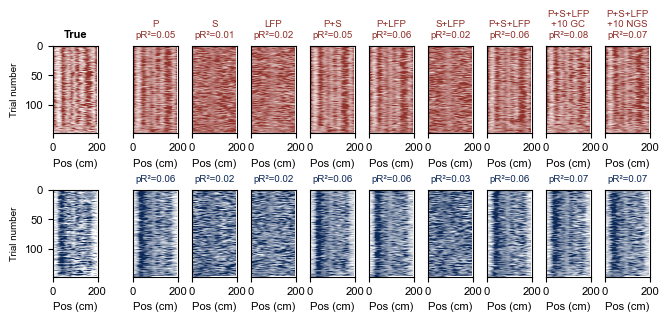

Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/M29D23_rate_map_reconstruction_2x10.pdf


In [ ]:
from scipy.ndimage import gaussian_filter
import matplotlib.gridspec as gridspec

grid_color = '#90312a'
ngs_color = '#0d2958'

# ── Config ────────────────────────────────────────────────────────────────────
plot_keys  = ['pos', 'speed', 'lfp',
              'pos_speed', 'pos_lfp', 'speed_lfp', 'pos_speed_lfp',
              'pos_g10_speed_lfp', 'pos_ngs10_speed_lfp']
col_titles = ['P', 'S', 'LFP', 'P+S', 'P+LFP', 'S+LFP', 'P+S+LFP',
              'P+S+LFP\n+10 GC', 'P+S+LFP\n+10 NGS']

target_cells = [
    (test_grid_cell_1, f'GC (unit {test_grid_cell_1})',  grid_color),
    (test_ngs_cell_1,  f'NGS (unit {test_ngs_cell_1})', ngs_color),
]
row_results = [
    results_dict[f'Unit {test_grid_cell_1}'],
    results_dict[f'Unit {test_ngs_cell_1}'],
]

# ── Pool real cluster IDs as pseudo IDs ───────────────────────────────────────
exclude_ids = {test_grid_cell_1, test_grid_cell_2, test_ngs_cell_1}
pool_ids = []
for src in [ns.cluster_id.values, sc.cluster_id.values, all_by_anatomy.cluster_id.values]:
    for cid in src:
        if cid not in exclude_ids and cid not in pool_ids:
            pool_ids.append(cid)

n_needed = len(plot_keys)
assert len(pool_ids) >= n_needed * 2, \
    f"Need {n_needed*2} pseudo IDs, found {len(pool_ids)}"
pseudo_ids_gc  = pool_ids[:n_needed]
pseudo_ids_ngs = pool_ids[n_needed:n_needed * 2]

# ── Batch Y_hat arrays → single reconstruction call ───────────────────────────
expected_spikes = {}
for col_i, key in enumerate(plot_keys):
    expected_spikes[pseudo_ids_gc[col_i]]  = row_results[0][key][0]
    expected_spikes[pseudo_ids_ngs[col_i]] = row_results[1][key][0]

tcs_recon, _, _, last_ephys_bin_r, _, _ = compute_vr_tcs_using_expected_spikes(
    mouse, day, apply_zscore=False, vr_type='VR', source_path=None,
    expected_spikes=expected_spikes)

def white_to_hex_cmap(hex_color, name='custom_cmap'):
    from matplotlib.colors import LinearSegmentedColormap
    return LinearSegmentedColormap.from_list(name, ['#FFFFFF', hex_color])

# ── Layout: 3 rows × N_COLS ───────────────────────────────────────────────────
# rows: [0] GC rate map | [1] row gap | [2] NGS rate map
# cols: [0] true | [1] col gap | [2..10] predictions
N_PRED     = len(plot_keys)   # 9
N_COLS     = 1 + 1 + N_PRED  # 11
GAP_COL    = 1
sigma      = 2.5
col_widths = [1.0, 0.15] + [1.0] * N_PRED

fig = plt.figure(figsize=(N_COLS * 0.7, 3))
gs  = gridspec.GridSpec(
    3, N_COLS, figure=fig,
    height_ratios=[1, 0.15, 1],
    width_ratios=col_widths,
    hspace=0.35,
    wspace=0.35,
)

subrow = [0, 2]  # GC → row 0, NGS → row 2

for row_i, (target_id, row_label, color) in enumerate(target_cells):
    results    = row_results[row_i]
    pseudo_ids = pseudo_ids_gc if row_i == 0 else pseudo_ids_ngs
    sr         = subrow[row_i]

    # ── Col 0: True ───────────────────────────────────────────────────────────
    tc_true = gaussian_filter(
        np.nan_to_num(tcs[target_id]).astype(np.float64), sigma=sigma)
    tc_true = tc_true[:last_ephys_bin]

    ax = fig.add_subplot(gs[sr, 0])
    plot_firing_rate_map(ax, tc_true, bs=bs, tl=tl, p=95, cmap=white_to_hex_cmap(color))
    ax.set_ylabel('Trial number', fontsize=8, labelpad=4)
    ax.tick_params(axis='both', labelsize=8)
    ax.set_xlabel('Pos (cm)', fontsize=8)
    if row_i == 0:
        ax.set_title('True', fontsize=8, fontweight='bold', color='black')

    # ── Col 1: GAP ────────────────────────────────────────────────────────────
    fig.add_subplot(gs[sr, GAP_COL]).axis('off')

    # ── Cols 2-10: Predictions ────────────────────────────────────────────────
    for col_i, (key, title) in enumerate(zip(plot_keys, col_titles)):
        fig_col = col_i + 2
        pid     = pseudo_ids[col_i]
        pr2     = np.nanmean(results[key][1])

        tc_r = gaussian_filter(
            np.nan_to_num(tcs_recon[pid]).astype(np.float64), sigma=sigma)
        tc_r = tc_r[:last_ephys_bin]

        ax = fig.add_subplot(gs[sr, fig_col])
        plot_firing_rate_map(ax, tc_r, bs=bs, tl=tl, p=95, cmap=white_to_hex_cmap(color))

        ax.set_yticks([])
        ax.set_yticklabels([])
        ax.set_xlabel('Pos (cm)', fontsize=8)
        ax.tick_params(axis='x', labelsize=8)
        if row_i == 0:
            ax.set_title(f'{title}\npR²={pr2:.2f}', fontsize=7, color=color)
        else:
            ax.set_title(f'pR²={pr2:.2f}', fontsize=7, color=color)

# ── Row gap: hide middle spacer ───────────────────────────────────────────────
for c in range(N_COLS):
    fig.add_subplot(gs[1, c]).axis('off')

savepath = (f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
            f'figure_4_xgboost/M{mouse}D{day}_rate_map_reconstruction_2x10.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved: {savepath}')


using expected spikes for cell 26
using expected spikes for cell 268
using expected spikes for cell 275
using expected spikes for cell 317
using expected spikes for cell 335
using expected spikes for cell 336
using expected spikes for cell 359
using expected spikes for cell 408
using expected spikes for cell 444
using expected spikes for cell 447


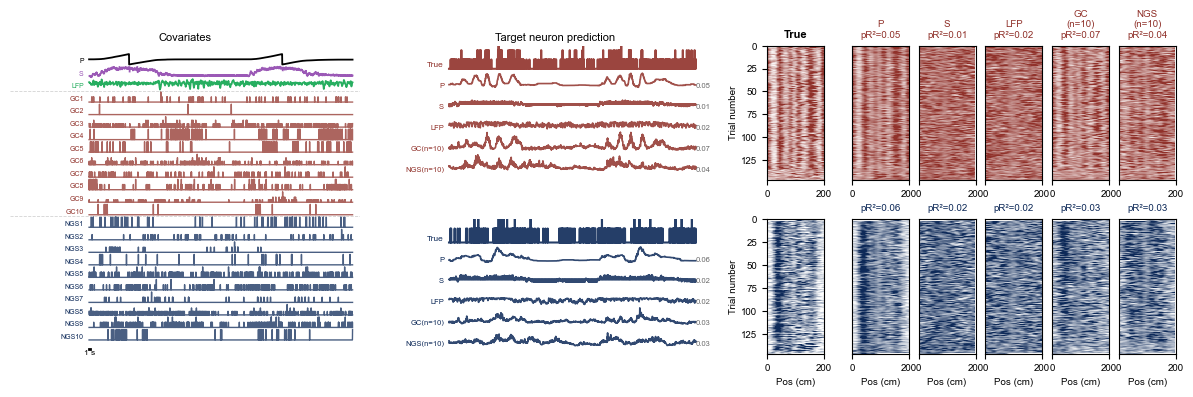

Saved: /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/M29D23_rate_map_cov_traces_combined.pdf


In [57]:
from scipy.ndimage import gaussian_filter
import matplotlib.gridspec as gridspec

grid_color = '#90312a'
ngs_color  = '#0d2958'

# ── Config ─────────────────────────────────────────────────────────────────────
trace_covariates = ['pos', 'speed', 'lfp', 'g10', 'ngs10']
trace_labels     = ['P', 'S', 'LFP', 'GC(n=10)', 'NGS(n=10)']
plot_keys        = trace_covariates
col_titles       = ['P', 'S', 'LFP', 'GC\n(n=10)', 'NGS\n(n=10)']

trace_window = (24150, 26250)
trace_gains  = [5, 6]

target_cells = [
    (test_grid_cell_1, f'GC (unit {test_grid_cell_1})',  grid_color),
    (test_ngs_cell_1,  f'NGS (unit {test_ngs_cell_1})', ngs_color),
]
row_results = [
    results_dict[f'Unit {test_grid_cell_1}'],
    results_dict[f'Unit {test_ngs_cell_1}'],
]

# ── Pool pseudo IDs ─────────────────────────────────────────────────────────────
exclude_ids = {test_grid_cell_1, test_grid_cell_2, test_ngs_cell_1}
pool_ids = []
for src in [ns.cluster_id.values, sc.cluster_id.values, all_by_anatomy.cluster_id.values]:
    for cid in src:
        if cid not in exclude_ids and cid not in pool_ids:
            pool_ids.append(cid)

n_needed = len(plot_keys)
assert len(pool_ids) >= n_needed * 2, f"Need {n_needed*2} pseudo IDs, found {len(pool_ids)}"
pseudo_ids_gc  = pool_ids[:n_needed]
pseudo_ids_ngs = pool_ids[n_needed:n_needed * 2]

# ── Batch reconstruction ────────────────────────────────────────────────────────
expected_spikes = {}
for col_i, key in enumerate(plot_keys):
    expected_spikes[pseudo_ids_gc[col_i]]  = row_results[0][key][0]
    expected_spikes[pseudo_ids_ngs[col_i]] = row_results[1][key][0]

tcs_recon, _, _, last_ephys_bin_r, _, _ = compute_vr_tcs_using_expected_spikes(
    mouse, day, apply_zscore=False, vr_type='VR', source_path=None,
    expected_spikes=expected_spikes)

def white_to_hex_cmap(hex_color, name='custom_cmap'):
    from matplotlib.colors import LinearSegmentedColormap
    return LinearSegmentedColormap.from_list(name, ['#FFFFFF', hex_color])

# ── Precompute covariate arrays ─────────────────────────────────────────────────
_lfp = np.array(get_theta_trace(
    mouse=mouse, day=day, cluster_id=test_grid_cell_1,
    time_bs=50, resample_bs=time_bs, vr_type='VR'))
n_t  = len(pos_in_time)
_lfp = _lfp[:n_t] if len(_lfp) >= n_t else np.pad(_lfp, (0, n_t - len(_lfp)))

gc_traces  = [np.array(tcs_time[cid]) for cid in grid_predictors[:10]]
ngs_traces = [np.array(tcs_time[cid]) for cid in ngs_predictors[:10]]

# ── Helpers ─────────────────────────────────────────────────────────────────────
def _norm01(arr, win):
    seg = np.array(arr)[win].astype(float)
    lo, hi = np.nanmin(seg), np.nanmax(seg)
    return (seg - lo) / (hi - lo + 1e-10)

def draw_all_covariates_on_ax(ax, pos_arr, speed_arr, lfp_arr,
                               gc_tr, ngs_tr, window, time_bs=100):
    win   = slice(window[0], window[1])
    t_idx = np.arange(window[0], window[1])
    h     = 1.2
    window_frac = (window[1]-window[0])*0.02

    traces = (
        [(pos_arr,   'P',   'black',   1.0, 1.3),
         (speed_arr, 'S',   '#9b59b6', 1.0, 1.3),
         (lfp_arr,   'LFP', '#27ae60', 1.0, 1.3)] +
        [(t, f'GC{i+1}',  grid_color, 0.75, 1.0) for i, t in enumerate(gc_tr)] +
        [(t, f'NGS{i+1}', ngs_color,  0.75, 1.0) for i, t in enumerate(ngs_tr)]
    )
    n = len(traces)  # 23

    for j, (arr, label, c, a, lw) in enumerate(traces):
        offset = h * (n - 1 - j)
        ax.plot(t_idx, _norm01(arr, win) + offset, lw=lw, alpha=a, color=c)
        ax.text(t_idx[0]-window_frac, offset + h * 0.05,
                label, ha='right', va='bottom', fontsize=5, color=c)

    for div_j in [3, 13]:
        ax.axhline(h * (n - div_j) - h * 0.1,
                   color='lightgray', lw=0.6, linestyle='--')

    bar_len = int(1000 / time_bs)
    bar_y   = -h * 0.7
    ax.plot([t_idx[0], t_idx[0] + bar_len], [bar_y, bar_y], 'k-', lw=2)
    ax.text(t_idx[0] + bar_len * 0.5, bar_y - h * 0.1,
            '1 s', ha='center', va='top', fontsize=6)

    lpad = len(t_idx) * 0.30
    ax.set_xlim(t_idx[0] - lpad, t_idx[-1] + len(t_idx) * 0.03)
    ax.set_ylim(bar_y - h * 0.4, h * n + 0.6)
    ax.axis('off')

def draw_traces_on_ax(ax, results, covariates, labels, window, gain, color, time_bs=100):
    win   = slice(window[0], window[1])
    t_idx = np.arange(window[0], window[1])
    window_frac = (window[1]-window[0])*0.02
    n     = len(covariates)

    true_trace  = results['y'][win]
    peak        = float(np.nanmax(np.abs(true_trace)))
    offset_step = peak * 1.5 if peak > 0 else 1.0
    true_offset = offset_step * n

    ax.plot(t_idx, true_trace * 2 + true_offset, lw=1.5, color=color, alpha=0.9, zorder=3)
    ax.text(t_idx[0]-window_frac, true_offset + offset_step * 0.05,
            'True', ha='right', va='bottom', fontsize=6, color=color)

    for j, (cov, label) in enumerate(zip(covariates, labels)):
        offset = offset_step * (n - 1 - j)
        pred   = results[cov][0][win]
        pr2    = np.nanmean(results[cov][1])
        ax.plot(t_idx, pred * gain + offset, lw=1.2, alpha=0.85, color=color)
        ax.text(t_idx[0]-window_frac,  offset + offset_step * 0.05,
                label, ha='right', va='bottom', fontsize=5.5, color=color)
        ax.text(t_idx[-1], offset + offset_step * 0.05,
                f'{pr2:.2f}', ha='left', va='bottom', fontsize=5.5, color='dimgray')

    lpad = len(t_idx) * 0.28
    rpad = len(t_idx) * 0.14
    ax.set_xlim(t_idx[0] - lpad, t_idx[-1] + rpad)
    ax.set_ylim(-offset_step * 0.3, true_offset + offset_step * 1.1)
    ax.axis('off')

# ── Layout ──────────────────────────────────────────────────────────────────────
N_PRED       = len(plot_keys)           # 5
_map_w       = 1.0 + 0.15 + N_PRED * 1.0
_sec         = _map_w
N_TOTAL_COLS = 1 + 1 + 1 + 1 + 1 + 1 + N_PRED   # 11
col_widths   = [_sec, 0, _sec, 0.3, 1.0, 0.15] + [1.0] * N_PRED
sigma        = 2.5

_total_w = _sec * 2 + 0.35 + _map_w
fig = plt.figure(figsize=(_total_w * 0.8, 4))
gs  = gridspec.GridSpec(
    3, N_TOTAL_COLS, figure=fig,
    height_ratios=[1, 0.15, 1],
    width_ratios=col_widths,
    hspace=0.10, wspace=0.10,
)

# ── Covariates column: spans all rows ──────────────────────────────────────────
ax_inputs = fig.add_subplot(gs[0:3, 0])
draw_all_covariates_on_ax(ax_inputs, pos_in_time, speed_in_time, _lfp,
                          gc_traces, ngs_traces, trace_window)
ax_inputs.set_title('Covariates', fontsize=8, pad=4)

# ── Per-row: predicted traces + rate maps ──────────────────────────────────────
subrow = [0, 2]

for row_i, (target_id, row_label, color) in enumerate(target_cells):
    results    = row_results[row_i]
    pseudo_ids = pseudo_ids_gc if row_i == 0 else pseudo_ids_ngs
    sr         = subrow[row_i]
    is_bottom  = row_i == 1

    fig.add_subplot(gs[sr, 1]).axis('off')

    ax_t = fig.add_subplot(gs[sr, 2])
    draw_traces_on_ax(ax_t, results, trace_covariates, trace_labels,
                      trace_window, trace_gains[row_i], color)
    if row_i == 0:
        ax_t.set_title('Target neuron prediction', fontsize=8, pad=4)

    fig.add_subplot(gs[sr, 3]).axis('off')

    # True rate map
    tc_true = gaussian_filter(
        np.nan_to_num(tcs[target_id]).astype(np.float64), sigma=sigma)
    tc_true = tc_true[:last_ephys_bin]

    ax = fig.add_subplot(gs[sr, 4])
    plot_firing_rate_map(ax, tc_true, bs=bs, tl=tl, p=95, cmap=white_to_hex_cmap(color))
    ax.set_ylabel('Trial number', fontsize=7, labelpad=2)
    ax.tick_params(axis='both', labelsize=7)
    ax.set_xlabel('Pos (cm)' if is_bottom else '', fontsize=7)
    if row_i == 0:
        ax.set_title('True', fontsize=8, fontweight='bold', color='black')

    fig.add_subplot(gs[sr, 5]).axis('off')

    for col_i, (key, title) in enumerate(zip(plot_keys, col_titles)):
        pid = pseudo_ids[col_i]
        pr2 = np.nanmean(results[key][1])

        tc_r = gaussian_filter(
            np.nan_to_num(tcs_recon[pid]).astype(np.float64), sigma=sigma)
        tc_r = tc_r[:last_ephys_bin]

        ax = fig.add_subplot(gs[sr, col_i + 6])
        plot_firing_rate_map(ax, tc_r, bs=bs, tl=tl, p=95, cmap=white_to_hex_cmap(color))
        ax.set_yticks([])
        ax.set_xlabel('Pos (cm)' if is_bottom else '', fontsize=7)
        ax.tick_params(axis='x', labelsize=7)
        if row_i == 0:
            ax.set_title(f'{title}\npR²={pr2:.2f}', fontsize=7, color=color)
        else:
            ax.set_title(f'pR²={pr2:.2f}', fontsize=7, color=color)

# ── Row spacer ──────────────────────────────────────────────────────────────────
for c in range(1, N_TOTAL_COLS):
    fig.add_subplot(gs[1, c]).axis('off')

savepath = (f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
            f'figure_4_xgboost/M{mouse}D{day}_rate_map_cov_traces_combined.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved: {savepath}')


In [ ]:
results_dict['Unit 214'][' ']

In [ ]:
for b in [-54000, -50000, -46000, -42000, -38000, -34000, -30000, -26000, -22000, -18000, -14000, -10000, -6000, -2000]:
    print(b)
    
    # Now you can call the plotting function
    plot_xgboost_traces(results_dict, 
                        target_cell_names,
                        window=(54200+b, 57200+b), 
                        figsize=(15, 9),
                        gain=[5, 12, 6],
                        text_offset=0.25,
                        offset_jump=0.3,
                        savepath=fig_path + f'M{mouse}D{day}_xgboost_traces_with_theta.pdf')

I need to work out how to add theta as a covariate
